# Otsu Thresholding

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

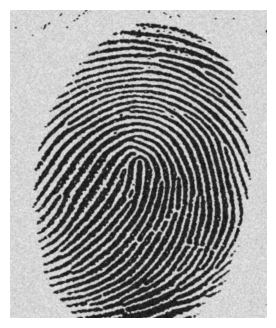

In [21]:
img=cv2.imread(r'E:\BG\fingerprint.tif',0)
plt.figure(figsize=(8, 4))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

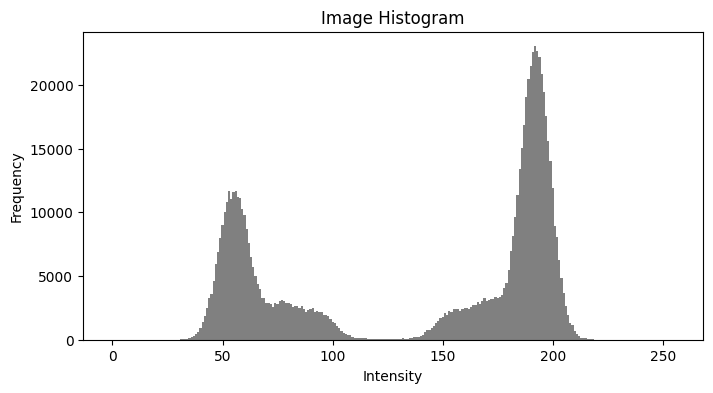

In [22]:
rows,cols=img.shape
total_pixels=rows*cols

hist=np.zeros(256, dtype=np.int32)
for i in range(rows):
    for j in range(cols):
        hist[img[i, j]] += 1

prob=hist/total_pixels
plt.figure(figsize=(8, 4))
plt.bar(range(256), hist, width=1, color='gray')
plt.title('Image Histogram')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.show()

In [23]:
max_variance=0
optimal_threshold=0

for t in range(256):
    w0=np.sum(prob[:t+1])
    if w0==0:
        continue
    mean0=np.sum(np.arange(t+1) * prob[:t+1]) / w0
    
    # Foreground class: pixels [t+1, 255]
    w1=np.sum(prob[t+1:])
    if w1==0:
        continue
    mean1=np.sum(np.arange(t+1, 256) * prob[t+1:]) / w1
    
    # Between-class variance
    between_var=w0*w1*(mean0-mean1)**2
    
    if between_var>max_variance:
        max_variance=between_var
        optimal_threshold=t

print(f'Optimal Threshold (Manual): {optimal_threshold}')
print(f'Maximum Between-Class Variance: {max_variance:.4f}')

Optimal Threshold (Manual): 125
Maximum Between-Class Variance: 3550.2945


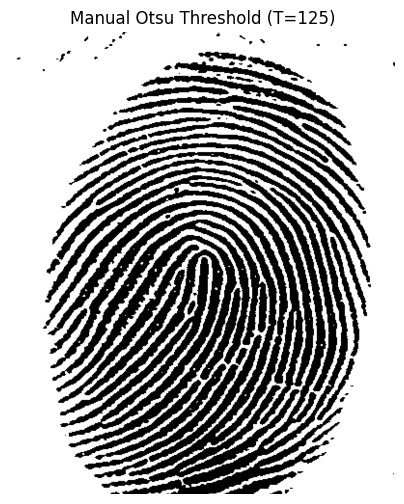

In [24]:
manual_thresh = np.zeros_like(img)
for i in range(rows):
    for j in range(cols):
        if img[i, j] >= optimal_threshold:
            manual_thresh[i, j] = 255
        else:
            manual_thresh[i, j] = 0

plt.figure(figsize=(10,6))
plt.imshow(manual_thresh, cmap='gray')
plt.title(f'Manual Otsu Threshold (T={optimal_threshold})')
plt.axis('off')
plt.show()